In [1]:
import xgboost as xgb
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 1. CREATE A MASSIVE DATASET
# We are creating 1 MILLION rows and 20 columns to make the CPU sweat.
print("Generating 1 Million rows of synthetic data... (Give it a few seconds)")
X, y = make_classification(n_samples=1000000, n_features=20, random_state=42)
print("Data generated! Let the race begin.\n")

# ---------------------------------------------------------
# 2. THE CPU RUN
# ---------------------------------------------------------
print("--- Starting CPU Training (The Professor) ---")
cpu_model = xgb.XGBClassifier(
    n_estimators=150,     # Number of trees
    max_depth=6,
    tree_method='hist',
    device='cpu',         # <-- FORCING CPU USAGE
    random_state=42
)

start_cpu = time.time()
cpu_model.fit(X, y)
end_cpu = time.time()

cpu_time = end_cpu - start_cpu
print(f"CPU Finished in: {cpu_time:.2f} seconds\n")

# ---------------------------------------------------------
# 3. THE GPU RUN
# ---------------------------------------------------------
print("--- Starting GPU Training (The Army) ---")
gpu_model = xgb.XGBClassifier(
    n_estimators=150,     # Exact same number of trees
    max_depth=6,
    tree_method='hist',
    device='cuda',        # <-- FORCING GPU USAGE
    random_state=42
)

start_gpu = time.time()
gpu_model.fit(X, y)
end_gpu = time.time()

gpu_time = end_gpu - start_gpu
print(f"GPU Finished in: {gpu_time:.2f} seconds\n")




Generating 1 Million rows of synthetic data... (Give it a few seconds)
Data generated! Let the race begin.

--- Starting CPU Training (The Professor) ---
CPU Finished in: 17.79 seconds

--- Starting GPU Training (The Army) ---
GPU Finished in: 5.33 seconds



 WINNER: GPU was 3.3x faster than the CPU!



Text(0.5, 1.0, 'CPU vs GPU: Training on 1 Million Rows')

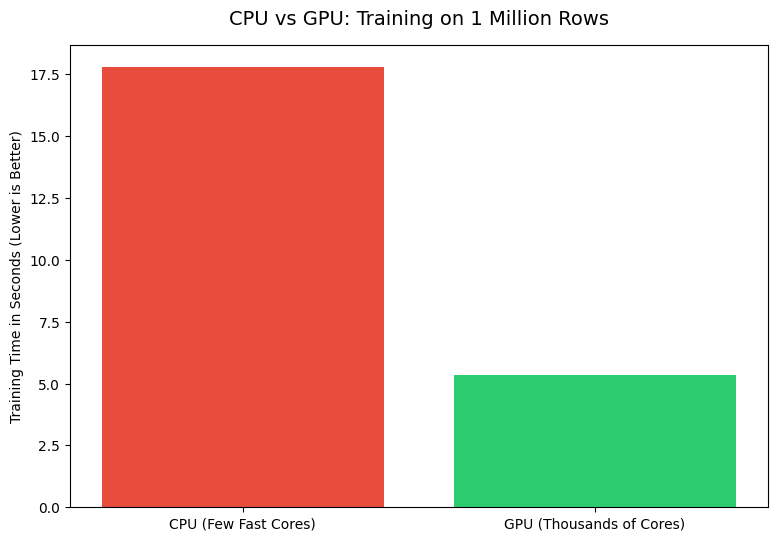

In [2]:
# ---------------------------------------------------------
# 4. VISUALIZE THE RESULTS
# ---------------------------------------------------------
speedup = cpu_time / gpu_time
print("==================================================")
print(f" WINNER: GPU was {speedup:.1f}x faster than the CPU!")
print("==================================================\n")

plt.figure(figsize=(9, 6))
bars = plt.bar(['CPU (Few Fast Cores)', 'GPU (Thousands of Cores)'],
               [cpu_time, gpu_time],
               color=['#e74c3c', '#2ecc71'])

plt.ylabel('Training Time in Seconds (Lower is Better)')
plt.title('CPU vs GPU: Training on 1 Million Rows', fontsize=14, pad=15)


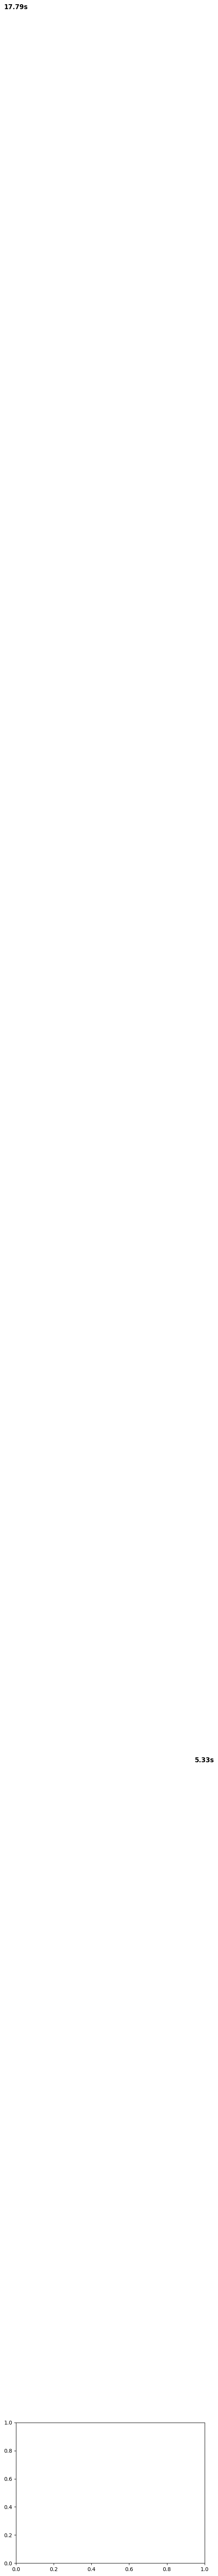

In [3]:
# Add the exact seconds on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(cpu_time, gpu_time)*0.02),
             f'{yval:.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.show()

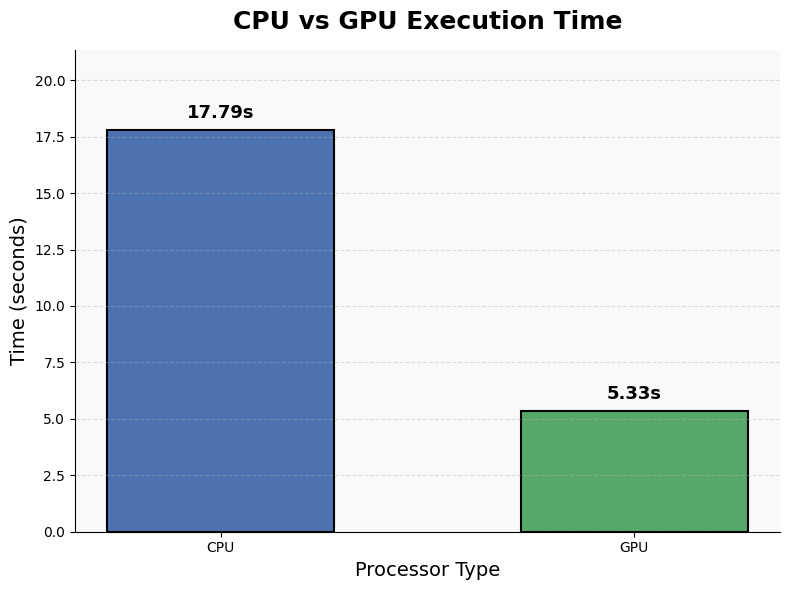

In [4]:
# Add the exact seconds on top of the bars
import matplotlib.pyplot as plt
import numpy as np

# Example data
labels = ['CPU', 'GPU']
times = [cpu_time, gpu_time]

# Colors
colors = ['#4C72B0', '#55A868']

# Create figure
plt.figure(figsize=(8, 6))

# Create bars
bars = plt.bar(labels, times, color=colors, width=0.55,
               edgecolor='black', linewidth=1.5)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + (max(times) * 0.02),
        f'{yval:.2f}s',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black'
    )

# Title and labels
plt.title('CPU vs GPU Execution Time', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Time (seconds)', fontsize=14)
plt.xlabel('Processor Type', fontsize=14)

# Grid styling
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve y-axis spacing
plt.ylim(0, max(times) * 1.2)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle background color
ax.set_facecolor('#F8F9FA')

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [5]:
import psutil
import subprocess
import os

def print_hardware_usage():
    print("=== CURRENT HARDWARE USAGE ===")

    # ---------------------------------------------------------
    # 1. CHECK SYSTEM RAM (CPU)
    # ---------------------------------------------------------
    # Get total system memory
    sys_mem = psutil.virtual_memory()
    total_ram = sys_mem.total / (1024 ** 3)      # Convert bytes to GB
    used_ram = sys_mem.used / (1024 ** 3)        # Convert bytes to GB
    ram_percent = sys_mem.percent

    # Get RAM used specifically by this Python process
    process = psutil.Process(os.getpid())
    proc_ram = process.memory_info().rss / (1024 ** 3)

    print("--- CPU / SYSTEM RAM ---")
    print(f"Total Colab RAM:  {total_ram:.2f} GB")
    print(f"Total Used RAM:   {used_ram:.2f} GB ({ram_percent}%)")
    print(f"Used by Python:   {proc_ram:.2f} GB")

    # ---------------------------------------------------------
    # 2. CHECK VRAM (GPU)
    # ---------------------------------------------------------
    print("\n--- GPU VRAM ---")
    try:
        # We ping nvidia-smi to give us the exact memory stats in a clean CSV format
        smi_query = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.used,memory.total,utilization.gpu', '--format=csv,nounits,noheader'],
            encoding='utf-8'
        )

        # Parse the output
        vram_used, vram_total, gpu_util = map(int, smi_query.strip().split(', '))
        vram_percent = (vram_used / vram_total) * 100

        print(f"Total GPU VRAM:   {vram_total / 1024:.2f} GB")
        print(f"Used GPU VRAM:    {vram_used / 1024:.2f} GB ({vram_percent:.1f}%)")
        print(f"GPU Core Utility: {gpu_util}% (How hard the cores are working)")

    except FileNotFoundError:
        print("No GPU detected! Make sure you are using a GPU runtime.")
    except Exception as e:
        print(f"Could not read GPU stats: {e}")

    print("==============================\n")

# Call the function to see your stats!
print_hardware_usage()

=== CURRENT HARDWARE USAGE ===
--- CPU / SYSTEM RAM ---
Total Colab RAM:  12.67 GB
Total Used RAM:   1.51 GB (14.2%)
Used by Python:   0.69 GB

--- GPU VRAM ---
Total GPU VRAM:   15.00 GB
Used GPU VRAM:    0.12 GB (0.8%)
GPU Core Utility: 0% (How hard the cores are working)

